# GREA-Patched CLASS 3.3.4 — Result Figures
**General Relativistic Entropic Acceleration (GREA) dark energy, García-Bellido 2024 (arXiv:2405.02895)**

All 16 validation gates passed before generating these figures.
Cell 0 enforces a freshness guard and three inline gate checks; subsequent cells will not run if any fails.


In [1]:
from classy import Class
import sys
import os
import glob
import datetime
import importlib.util
import numpy as np

# ── ROOT detection ────────────────────────────────────────────────────────────
_ROOT_CANDIDATE = os.path.abspath(os.getcwd())
if not os.path.exists(os.path.join(_ROOT_CANDIDATE, 'source', 'background.c')):
    _ROOT_CANDIDATE = os.path.abspath(os.path.join(_ROOT_CANDIDATE, '..'))
if not os.path.exists(os.path.join(_ROOT_CANDIDATE, 'source', 'background.c')):
    raise RuntimeError(
        "Cannot locate CLASS root (source/background.c not found). "
        "Start Jupyter from class_public-3.3.4/."
    )
ROOT = _ROOT_CANDIDATE
sys.path.insert(0, ROOT)
print(f"ROOT = {ROOT}")

# ── Import check_binary_freshness from validate_grea.py ──────────────────────
_spec = importlib.util.spec_from_file_location(
    'validate_grea', os.path.join(ROOT, 'scripts', 'validate_grea.py'))
_vg = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_vg)

BINARY_FRESH = False
try:
    _vg.check_binary_freshness()    # prints timestamps; sys.exit(1) if stale
    BINARY_FRESH = True
except SystemExit:
    print("\n⛔  STALE BINARY — rebuild before plotting:")
    print("    cd class_public-3.3.4")
    print("    make libclass.a")
    print("    python setup.py build_ext --inplace")

if not BINARY_FRESH:
    raise RuntimeError(
        "Stale binary — see message above. Rebuild and re-run Cell 0.")

# ── Inline gate subset (background only → fast) ───────────────────────────────
_BASE = {
    'omega_b': 0.02237, 'omega_cdm': 0.1200, 'h': 0.70,
    'A_s': 2.1e-9, 'n_s': 0.9649, 'tau_reio': 0.0544,
    'output': '', 'base_path': ROOT,
}
_cl = Class()
_cl.set({**_BASE, 'fluid_equation_of_state': 'CLP',
         'w0_fld': -1., 'wa_fld': 0., 'cs2_fld': 1.})
_cl.compute()
_cg = Class()
_cg.set({**_BASE, 'fluid_equation_of_state': 'GREA',
         'sqrt_k_eta0': 3.6, 'cs2_fld': 1., 'use_ppf': 'yes'})
_cg.compute()

_bg_g = _cg.get_background()
_z_w = np.sort(np.array(_bg_g['z']))
_w_fld = np.array(_bg_g['(.)w_fld'])[np.argsort(np.array(_bg_g['z']))]
_w0 = float(np.interp(0., _z_w, _w_fld))
_rs_l = _cl.get_current_derived_parameters(['rs_rec'])['rs_rec']
_rs_g = _cg.get_current_derived_parameters(['rs_rec'])['rs_rec']

_g1_ok = abs(_cg.h() - _cl.h()) < 1e-7
_g2_ok = abs(_rs_g/_rs_l - 1.) < 1e-4
_g7_ok = abs(_w0 + 1.) < 0.02

print("\n── Inline gate checks (background only) ────────────────────────────")
print(f"  G1  H0 shared  (|Δh| < 1e-7):          {'PASS ✓' if _g1_ok else 'FAIL ✗'}  "
      f"LCDM h={_cl.h():.9f}  GREA h={_cg.h():.9f}")
print(f"  G2  r_s(rec) preserved (|Δ| < 1e-4):   {'PASS ✓' if _g2_ok else 'FAIL ✗'}  "
      f"Δr_s/r_s={_rs_g/_rs_l - 1.:.3e}")
print(f"  G7a w0 ≈ -1 (|w0+1| < 0.02):           {'PASS ✓' if _g7_ok else 'FAIL ✗'}  "
      f"w0={_w0:.6f}")

_cl.struct_cleanup()
_cl.empty()
_cg.struct_cleanup()
_cg.empty()

GATES_OK = _g1_ok and _g2_ok and _g7_ok
if not GATES_OK:
    raise RuntimeError(
        "One or more inline gates FAILED — check binary and source.")
print("\n✅  Binary fresh, inline gates passed. Proceed to Cell 1.")

ROOT = /Users/simonedonofrio/Desktop/CLASS/class_public-3.3.4
BINARY FRESHNESS CHECK
  _classy.so      : 2026-06-18 14:55:17  (_classy.cpython-313-darwin.so)
  background.c    : 2026-06-18 14:54:39
  perturbations.c : 2025-11-24 14:18:20
  FRESH ✓  .so is newer than both source files.

── Inline gate checks (background only) ────────────────────────────
  G1  H0 shared  (|Δh| < 1e-7):          PASS ✓  LCDM h=0.700000000  GREA h=0.700000000
  G2  r_s(rec) preserved (|Δ| < 1e-4):   PASS ✓  Δr_s/r_s=-8.538e-08
  G7a w0 ≈ -1 (|w0+1| < 0.02):           PASS ✓  w0=-0.992110

✅  Binary fresh, inline gates passed. Proceed to Cell 1.


## Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np, os, datetime

assert BINARY_FRESH and GATES_OK, "Re-run Cell 0 first."

# ── Figure output directory (versioned, never overwrite) ──────────────────────
FIGURES_DIR = os.path.join(ROOT, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
RUN_TS = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, f'{name}_{RUN_TS}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  saved → {os.path.basename(path)}")

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 10,
    'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 1.8,
})

# ── Common cosmological parameters ───────────────────────────────────────────
# Parameter names verified against source/input.c lines 3614-3624 (GREA),
# 3580-3604 (CLP), 2278/2283 (h), 1886-1945 (output string matching).
COMMON = {
    'omega_b': 0.02237, 'omega_cdm': 0.1200, 'h': 0.70,
    'A_s': 2.1e-9, 'n_s': 0.9649, 'tau_reio': 0.0544,
    'output': 'tCl pCl lCl mPk',
    'lensing': 'yes',
    'P_k_max_1/Mpc': 5.0,
    'z_max_pk': 3.0,
    'l_max_scalars': 2500,
    'base_path': ROOT,
}
LCDM_P  = {**COMMON, 'fluid_equation_of_state': 'CLP',
            'w0_fld': -1., 'wa_fld': 0., 'cs2_fld': 1.}
GREA1_P = {**COMMON, 'fluid_equation_of_state': 'GREA',
            'sqrt_k_eta0': 3.6, 'cs2_fld': 1.0, 'use_ppf': 'yes'}
GREA0_P = {**COMMON, 'fluid_equation_of_state': 'GREA',
            'sqrt_k_eta0': 3.6, 'cs2_fld': 0.0, 'use_ppf': 'yes'}

_C_KMS = 2.99792458e5   # km/s

print("Parameters defined. Building CLASS instances (may take ~2 min)...")


Parameters defined. Building CLASS instances (may take ~2 min)...


In [3]:
from classy import Class


def build(params):
    c = Class()
    c.set(params)
    c.compute()
    return c


lcdm = build(LCDM_P)
grea1 = build(GREA1_P)   # GREA cs²=1
grea0 = build(GREA0_P)   # GREA cs²=0

# Cache background tables once (reused by all sections)
bg_l = lcdm.get_background()
bg_g1 = grea1.get_background()
bg_g0 = grea0.get_background()

print("All three instances built successfully.")
print(f"  LCDM  h={lcdm.h():.6f}  sigma8={lcdm.sigma8():.6f}")
print(f"  GREA1 h={grea1.h():.6f}  sigma8={grea1.sigma8():.6f}")
print(f"  GREA0 h={grea0.h():.6f}  sigma8={grea0.sigma8():.6f}")

All three instances built successfully.
  LCDM  h=0.700000  sigma8=0.830008
  GREA1 h=0.700000  sigma8=0.842895
  GREA0 h=0.700000  sigma8=0.842186


In [4]:
def bg_sorted(bg, *keys):
    z = np.array(bg['z'])
    idx = np.argsort(z)
    z = z[idx]
    return (z,) + tuple(np.array(bg[k])[idx] for k in keys)


def interp1(z_target, z_arr, y_arr):
    return float(np.interp(z_target, z_arr, y_arr))


COLORS = {'lcdm': '#333333', 'grea1': '#1f77b4', 'grea0': '#d62728'}
LABELS = {'lcdm': 'LCDM', 'grea1': 'GREA cs²=1', 'grea0': 'GREA cs²=0'}

print("Helpers defined.")

Helpers defined.


---
## Section A — Background Quantities

These figures compare the GREA and LCDM expansion histories, for visual comparison
with García-Bellido 2024 (arXiv:2405.02895). Key GREA feature: a transient
*slow-down* of expansion at 0.5 ≲ z ≲ 2 (H_GREA < H_LCDM in that epoch), followed
by catch-up to match today's H₀.


  saved → A1_Hz_ratio_20260618_154539.png


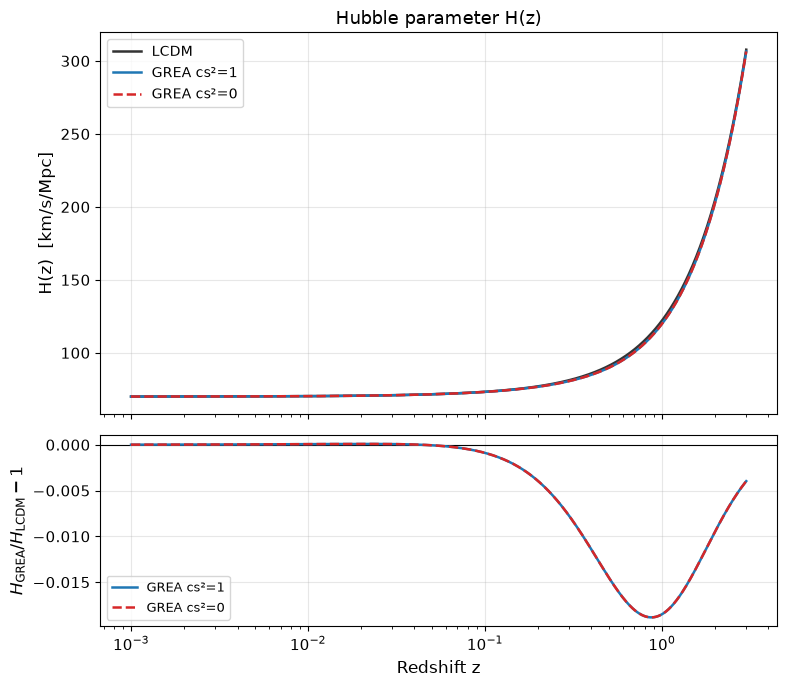

In [5]:
# ── A1: H(z) and H_GREA/H_LCDM − 1 ─────────────────────────────────────────
z_l, H_l = bg_sorted(bg_l, 'H [1/Mpc]')
z_g1, H_g1 = bg_sorted(bg_g1, 'H [1/Mpc]')
z_g0, H_g0 = bg_sorted(bg_g0, 'H [1/Mpc]')

z_plot = np.logspace(-3, np.log10(3.), 1000)
Hl = np.interp(z_plot, z_l,  H_l) * _C_KMS
Hg1 = np.interp(z_plot, z_g1, H_g1) * _C_KMS
Hg0 = np.interp(z_plot, z_g0, H_g0) * _C_KMS

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
ax, axr = axes

ax.plot(z_plot, Hl,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.plot(z_plot, Hg1, color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_plot, Hg0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_ylabel('H(z)  [km/s/Mpc]')
ax.set_xscale('log')
ax.legend()
ax.set_title('Hubble parameter H(z)')

axr.axhline(0, color='k', lw=0.8)
axr.plot(z_plot, Hg1/Hl - 1., color=COLORS['grea1'], label=LABELS['grea1'])
axr.plot(z_plot, Hg0/Hl - 1.,
         color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
axr.set_ylabel(r'$H_{\rm GREA}/H_{\rm LCDM} - 1$')
axr.set_xlabel('Redshift z')
axr.legend(fontsize=9)

plt.tight_layout()
save_fig(fig, 'A1_Hz_ratio')
plt.show()

  saved → A2_w_trajectory_20260618_154539.png


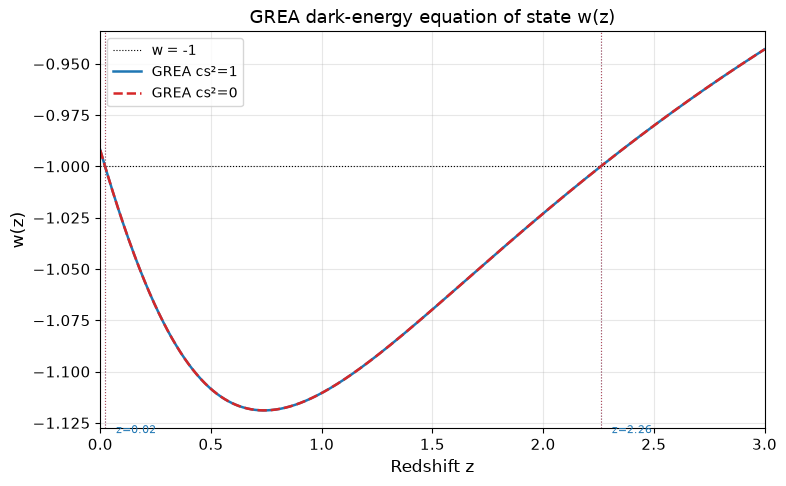

  cs²=1 phantom crossings at z ≈ ['0.021', '2.261']
  cs²=0 phantom crossings at z ≈ ['0.021', '2.261']


In [6]:
# ── A2: w(a) trajectory with phantom crossings ───────────────────────────────
z_g1, w_g1 = bg_sorted(bg_g1, '(.)w_fld')
z_g0, w_g0 = bg_sorted(bg_g0, '(.)w_fld')

z_w = np.linspace(0., 3., 2000)
w1 = np.interp(z_w, z_g1, w_g1)
w0_ = np.interp(z_w, z_g0, w_g0)

# Locate phantom crossings (w = -1)


def phantom_crossings(z_arr, w_arr):
    wp1 = w_arr + 1.
    sc = np.where(np.diff(np.sign(wp1)))[0]
    return [z_arr[i] + (0-wp1[i])*(z_arr[i+1]-z_arr[i])/(wp1[i+1]-wp1[i]) for i in sc]


xings1 = phantom_crossings(z_w, w1)
xings0 = phantom_crossings(z_w, w0_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(-1., color='k', lw=0.8, ls=':', label='w = -1')
ax.plot(z_w, w1,  color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_w, w0_, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
for zc in xings1:
    ax.axvline(zc, color=COLORS['grea1'], lw=0.8, ls=':', alpha=0.7)
    ax.text(zc+0.05, -1.13, f'z={zc:.2f}', color=COLORS['grea1'], fontsize=8)
for zc in xings0:
    ax.axvline(zc, color=COLORS['grea0'], lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Redshift z')
ax.set_ylabel('w(z)')
ax.set_xlim(0., 3.)
ax.legend()
ax.set_title('GREA dark-energy equation of state w(z)')
plt.tight_layout()
save_fig(fig, 'A2_w_trajectory')
plt.show()
print(f"  cs²=1 phantom crossings at z ≈ {[f'{x:.3f}' for x in xings1]}")
print(f"  cs²=0 phantom crossings at z ≈ {[f'{x:.3f}' for x in xings0]}")

  saved → A3_Omega_fld_20260618_154539.png


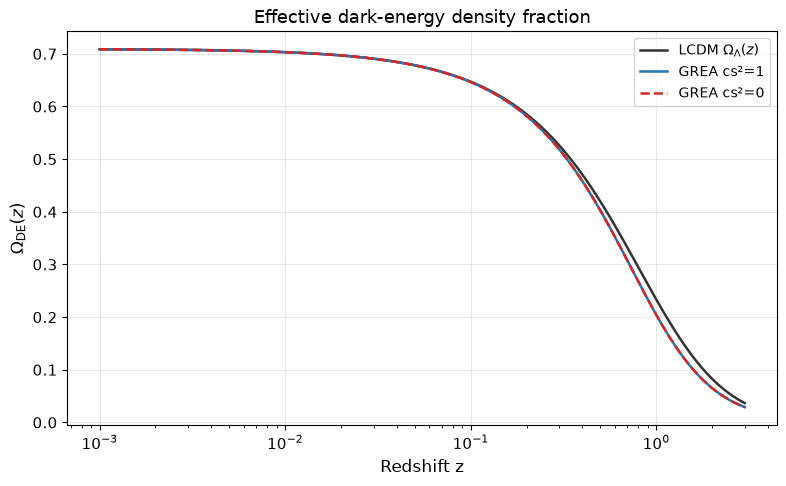

In [7]:
# ── A3: Effective dark-energy density Ω_fld(z) ───────────────────────────────
# LCDM: cosmological constant → rho_lambda / rho_crit
# GREA: fluid → rho_fld / rho_crit
z_l,  rc_l,  rl_l = bg_sorted(bg_l,  '(.)rho_crit', '(.)rho_lambda')
z_g1, rc_g1, rfl_g1 = bg_sorted(bg_g1, '(.)rho_crit', '(.)rho_fld')
z_g0, rc_g0, rfl_g0 = bg_sorted(bg_g0, '(.)rho_crit', '(.)rho_fld')

z_p = np.logspace(-3, np.log10(3.), 1000)
OmL = np.interp(z_p, z_l,  rl_l / rc_l)
Omg1 = np.interp(z_p, z_g1, rfl_g1 / rc_g1)
Omg0 = np.interp(z_p, z_g0, rfl_g0 / rc_g0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_p, OmL,  color=COLORS['lcdm'],  label=r'LCDM $\Omega_\Lambda(z)$')
ax.plot(z_p, Omg1, color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_p, Omg0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xscale('log')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$\Omega_{\rm DE}(z)$')
ax.set_title('Effective dark-energy density fraction')
ax.legend()
plt.tight_layout()
save_fig(fig, 'A3_Omega_fld')
plt.show()

  saved → A4_distances_20260618_154539.png


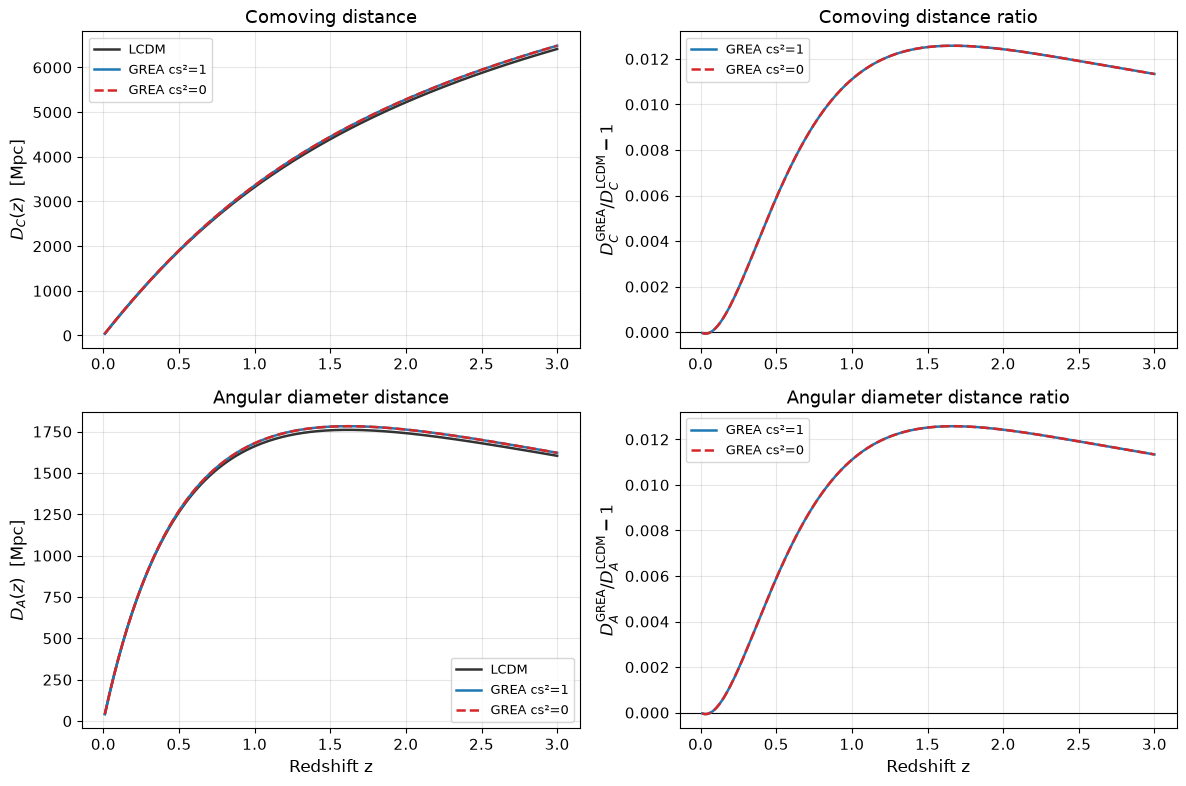

In [8]:
# ── A4: Comoving D_C(z) and angular-diameter D_A(z) ─────────────────────────
z_dist = np.linspace(0.01, 3., 200)
DC_l = np.array([lcdm.comoving_distance(z) for z in z_dist])
DC_g1 = np.array([grea1.comoving_distance(z) for z in z_dist])
DC_g0 = np.array([grea0.comoving_distance(z) for z in z_dist])
DA_l = np.array([lcdm.angular_distance(z) for z in z_dist])
DA_g1 = np.array([grea1.angular_distance(z) for z in z_dist])
DA_g0 = np.array([grea0.angular_distance(z) for z in z_dist])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(ax1, ax2), (ax3, ax4) = axes

ax1.plot(z_dist, DC_l,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax1.plot(z_dist, DC_g1, color=COLORS['grea1'], label=LABELS['grea1'])
ax1.plot(z_dist, DC_g0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax1.set_ylabel(r'$D_C(z)$  [Mpc]')
ax1.set_title('Comoving distance')
ax1.legend(fontsize=9)

ax2.axhline(0, color='k', lw=0.8)
ax2.plot(z_dist, DC_g1/DC_l - 1., color=COLORS['grea1'], label=LABELS['grea1'])
ax2.plot(z_dist, DC_g0/DC_l - 1.,
         color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax2.set_ylabel(r'$D_C^{\rm GREA}/D_C^{\rm LCDM} - 1$')
ax2.set_title('Comoving distance ratio')
ax2.legend(fontsize=9)

ax3.plot(z_dist, DA_l,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax3.plot(z_dist, DA_g1, color=COLORS['grea1'], label=LABELS['grea1'])
ax3.plot(z_dist, DA_g0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax3.set_xlabel('z')
ax3.set_ylabel(r'$D_A(z)$  [Mpc]')
ax3.set_title('Angular diameter distance')
ax3.legend(fontsize=9)

ax4.axhline(0, color='k', lw=0.8)
ax4.plot(z_dist, DA_g1/DA_l - 1., color=COLORS['grea1'], label=LABELS['grea1'])
ax4.plot(z_dist, DA_g0/DA_l - 1.,
         color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax4.set_xlabel('z')
ax4.set_ylabel(r'$D_A^{\rm GREA}/D_A^{\rm LCDM} - 1$')
ax4.set_title('Angular diameter distance ratio')
ax4.legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Redshift z') if ax in (ax3, ax4) else None
plt.tight_layout()
save_fig(fig, 'A4_distances')
plt.show()

  saved → A5_deceleration_20260618_154539.png


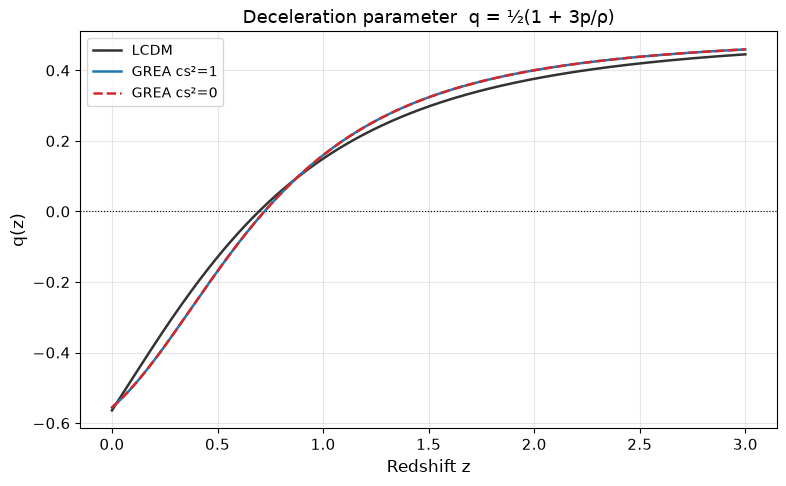

  q(z=0): LCDM=-0.5640  GREA1=-0.5556  GREA0=-0.5556


In [9]:
# ── A5: Deceleration parameter q(z) ──────────────────────────────────────────
# q = ½(1 + 3 p_tot/ρ_tot)  from background table (verified: p_tot key present)
def q_from_bg(bg):
    z, rho, p = bg_sorted(bg, '(.)rho_tot', '(.)p_tot')
    return z, 0.5 * (1. + 3. * p / rho)


z_ql, q_l = q_from_bg(bg_l)
z_qg1, q_g1 = q_from_bg(bg_g1)
z_qg0, q_g0 = q_from_bg(bg_g0)

z_p = np.linspace(0., 3., 1000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.plot(z_p, np.interp(z_p, z_ql,  q_l),
        color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.plot(z_p, np.interp(z_p, z_qg1, q_g1),
        color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_p, np.interp(z_p, z_qg0, q_g0),
        color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel('Redshift z')
ax.set_ylabel('q(z)')
ax.set_title('Deceleration parameter  q = ½(1 + 3p/ρ)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'A5_deceleration')
plt.show()
print(f"  q(z=0): LCDM={interp1(0., z_ql, q_l):.4f}  "
      f"GREA1={interp1(0., z_qg1, q_g1):.4f}  "
      f"GREA0={interp1(0., z_qg0, q_g0):.4f}")

---
## Section B — Structure Growth

At **fixed A_s**, GREA enhances growth relative to LCDM because the transient slow-down in H(z)
at 0.5 ≲ z ≲ 2 reduces Hubble friction in the growth equation, allowing more accumulation of structure.
This means GREA *worsens* the S8 tension rather than easing it — see the printed table for σ₈ and S8 values.

Note: `scale_independent_growth_factor_f(z)` solves D″ + aH D′ = (3/2)a²ρ_M D with ρ_M = baryons + CDM only.


  saved → B1_fsigma8_20260618_154539.png


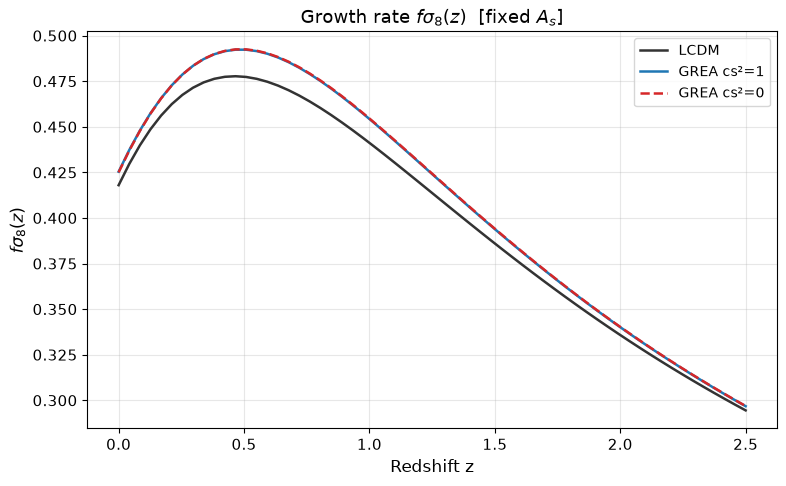

In [10]:
# ── B1: f·σ₈(z) ──────────────────────────────────────────────────────────────
z_b = np.linspace(0., 2.5, 60)
R8_l = 8. / lcdm.h()   # 8 Mpc/h in Mpc
R8_g1 = 8. / grea1.h()
R8_g0 = 8. / grea0.h()  # all identical (h=0.70)

fs8_l = np.array([lcdm.scale_independent_growth_factor_f(z)
                 * lcdm.sigma(R8_l,  z) for z in z_b])
fs8_g1 = np.array([grea1.scale_independent_growth_factor_f(z)
                  * grea1.sigma(R8_g1, z) for z in z_b])
fs8_g0 = np.array([grea0.scale_independent_growth_factor_f(z)
                  * grea0.sigma(R8_g0, z) for z in z_b])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_b, fs8_l,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.plot(z_b, fs8_g1, color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_b, fs8_g0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$f\sigma_8(z)$')
ax.set_title(r'Growth rate $f\sigma_8(z)$  [fixed $A_s$]')
ax.legend()
plt.tight_layout()
save_fig(fig, 'B1_fsigma8')
plt.show()

  saved → B2_sigma8z_20260618_154539.png


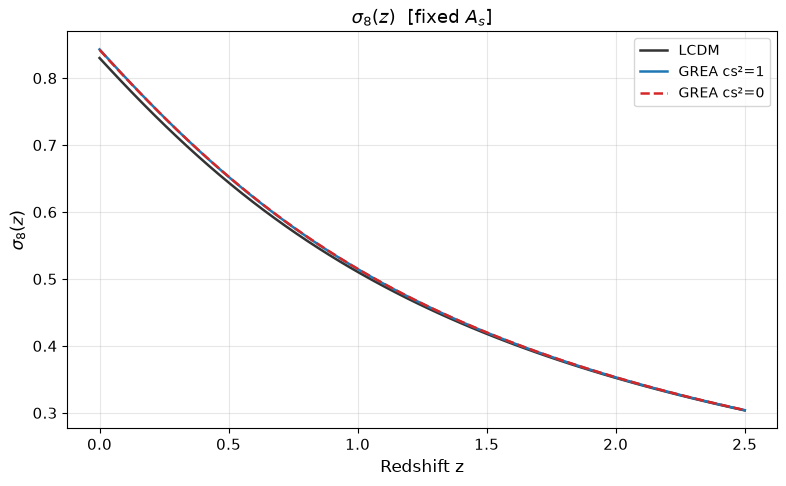

In [11]:
# ── B2: σ₈(z) ────────────────────────────────────────────────────────────────
s8_l = np.array([lcdm.sigma(R8_l,  z) for z in z_b])
s8_g1 = np.array([grea1.sigma(R8_g1, z) for z in z_b])
s8_g0 = np.array([grea0.sigma(R8_g0, z) for z in z_b])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_b, s8_l,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.plot(z_b, s8_g1, color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_b, s8_g0, color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$\sigma_8(z)$')
ax.set_title(r'$\sigma_8(z)$  [fixed $A_s$]')
ax.legend()
plt.tight_layout()
save_fig(fig, 'B2_sigma8z')
plt.show()

  saved → B3_D_ratio_20260618_154539.png


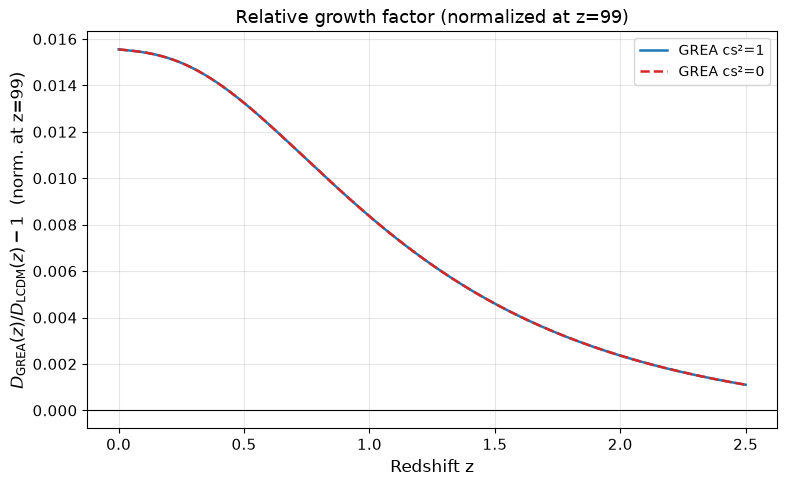

In [12]:
# ── B3: D_GREA/D_LCDM − 1  (normalized at z_norm = 99) ────────────────────
# scale_independent_growth_factor(z) is normalized to D(z=0)=1.
# To compare shapes, we renormalize both to D(z_norm) = 1.
z_norm = 99.
z_d = np.linspace(0., 2.5, 200)

D_l = np.array([lcdm.scale_independent_growth_factor(z) for z in z_d])
D_g1 = np.array([grea1.scale_independent_growth_factor(z) for z in z_d])
D_g0 = np.array([grea0.scale_independent_growth_factor(z) for z in z_d])
D_l_n = lcdm.scale_independent_growth_factor(z_norm)
D_g1_n = grea1.scale_independent_growth_factor(z_norm)
D_g0_n = grea0.scale_independent_growth_factor(z_norm)

# Renormalize so D(z_norm)=1 for each model
D_l_r = D_l / D_l_n
D_g1_r = D_g1 / D_g1_n
D_g0_r = D_g0 / D_g0_n

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='k', lw=0.8)
ax.plot(z_d, D_g1_r/D_l_r - 1., color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(z_d, D_g0_r/D_l_r - 1.,
        color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$D_{\rm GREA}(z)/D_{\rm LCDM}(z) - 1$  (norm. at z=99)')
ax.set_title('Relative growth factor (normalized at z=99)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'B3_D_ratio')
plt.show()

In [13]:
# ── B4: Summary table ─────────────────────────────────────────────────────────
from IPython.display import display, Markdown

z_tab = [0.0, 0.5, 1.0]
rows = []
for label, c, R8 in [('LCDM',   lcdm,  R8_l),
                     ('GREA cs²=1', grea1, R8_g1),
                     ('GREA cs²=0', grea0, R8_g0)]:
    s8_0 = c.sigma8()
    S8 = c.S8()
    Omm = c.Omega_m()
    fs8s = [c.scale_independent_growth_factor_f(
        z)*c.sigma(R8, z) for z in z_tab]
    rows.append((label, s8_0, S8, Omm, *fs8s))

header = "| Model | σ₈(0) | S8 | Ωm | fσ8(z=0) | fσ8(z=0.5) | fσ8(z=1) |"
sep = "|" + "|".join(["---"]*8) + "|"
lines = [header, sep]
for r in rows:
    lines.append(f"| {r[0]} | {r[1]:.5f} | {r[2]:.5f} | {r[3]:.5f} | "
                 f"{r[4]:.5f} | {r[5]:.5f} | {r[6]:.5f} |")
display(Markdown("\n".join(lines)))

| Model | σ₈(0) | S8 | Ωm | fσ8(z=0) | fσ8(z=0.5) | fσ8(z=1) |
|---|---|---|---|---|---|---|---|
| LCDM | 0.83001 | 0.81683 | 0.29055 | 0.41799 | 0.47747 | 0.44120 |
| GREA cs²=1 | 0.84290 | 0.82951 | 0.29055 | 0.42537 | 0.49234 | 0.45430 |
| GREA cs²=0 | 0.84219 | 0.82882 | 0.29055 | 0.42502 | 0.49252 | 0.45456 |

**Fixed-A_s note:** All three models share the same primordial amplitude A_s = 2.1×10⁻⁹.
GREA produces **more growth** than LCDM (σ₈_GREA > σ₈_LCDM) because the transient slow-down
in H(z) at z ≈ 0.5–2 reduces Hubble friction in the growth equation.
This means GREA **worsens** the S8 tension at fixed A_s — it is not a forward prediction
that GREA eases S8 without further parameter adjustment (e.g. lower A_s or different sqrt_k_eta0).


---
## Section C — Matter Power Spectrum  (linear only)

Non-linear corrections (Halofit / HMcode) are **not** applied here; this is the linear-theory P(k).
The ratio P_GREA/P_LCDM − 1 on a linear y-axis (C3) is where the GREA signal is clearly visible.


  saved → C1_Pk_20260618_154539.png


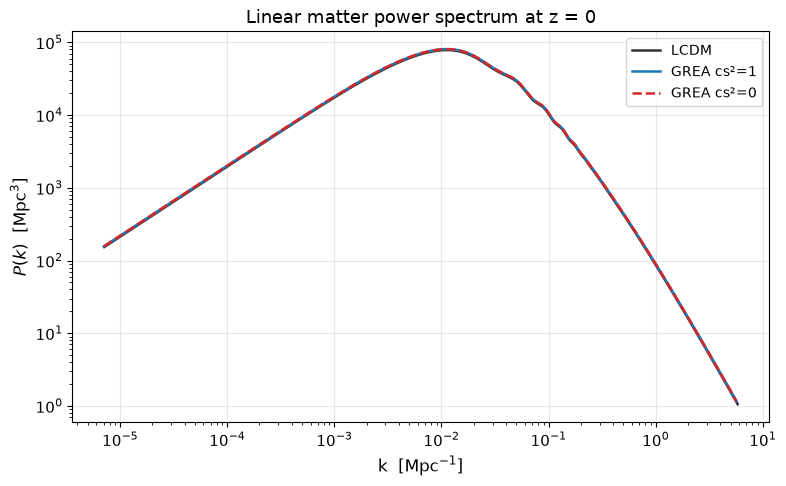

  saved → C2_Delta2k_20260618_154539.png


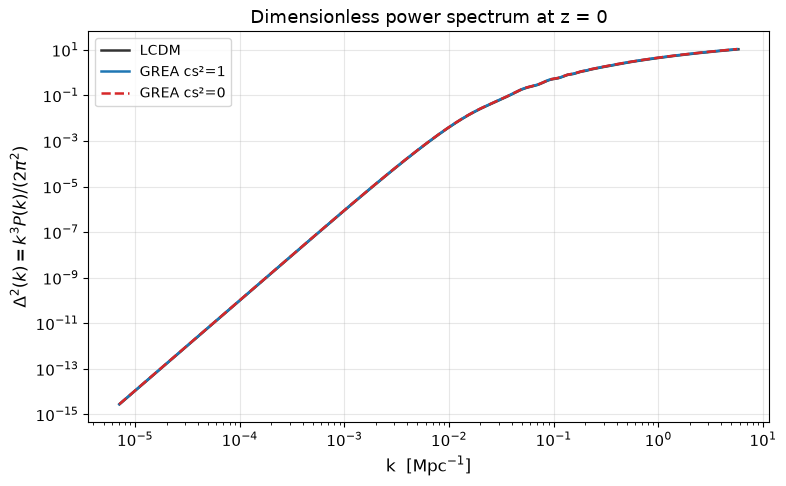

  saved → C3_Pk_ratio_20260618_154539.png


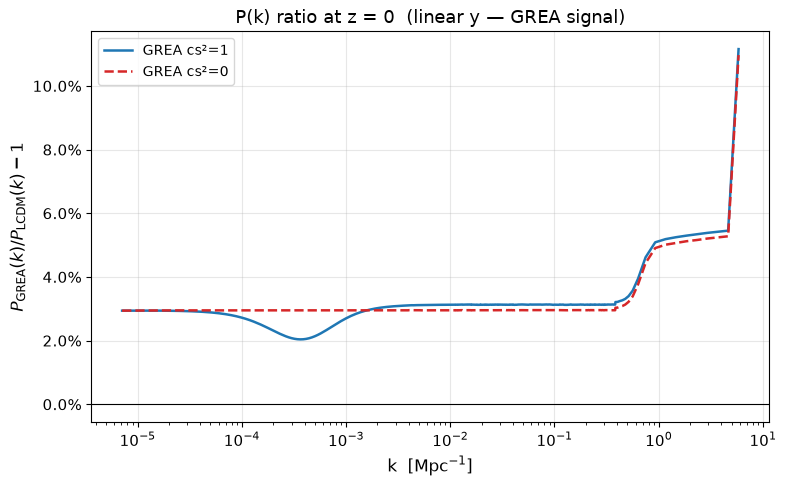

In [14]:
# ── C1 & C2 & C3: P(k) at z=0 ────────────────────────────────────────────────
# Use get_pk_and_k_and_z(nonlinear=False) to get a common k grid
pk_l,  k_l,  z_l_pk = lcdm.get_pk_and_k_and_z(nonlinear=False)
pk_g1, k_g1, z_g1_pk = grea1.get_pk_and_k_and_z(nonlinear=False)
pk_g0, k_g0, z_g0_pk = grea0.get_pk_and_k_and_z(nonlinear=False)

# z_arr is decreasing → last column is z=0 (or nearest)
iz0_l = np.argmin(np.abs(z_l_pk))
iz0_g1 = np.argmin(np.abs(z_g1_pk))
iz0_g0 = np.argmin(np.abs(z_g0_pk))

Pkl = pk_l[:,  iz0_l]    # P(k, z≈0)
Pkg1 = pk_g1[:, iz0_g1]
Pkg0 = pk_g0[:, iz0_g0]
kl = k_l
kg1 = k_g1
kg0 = k_g0

# Interpolate GREA onto LCDM k grid for ratio
Pkg1_i = np.interp(kl, kg1, Pkg1)
Pkg0_i = np.interp(kl, kg0, Pkg0)

# ── C1: log-log P(k) ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(kl,  Pkl,   color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.loglog(kg1, Pkg1,  color=COLORS['grea1'], label=LABELS['grea1'])
ax.loglog(kg0, Pkg0,  color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$P(k)$  [Mpc$^3$]')
ax.set_title('Linear matter power spectrum at z = 0')
ax.legend()
plt.tight_layout()
save_fig(fig, 'C1_Pk')
plt.show()

# ── C2: Δ²(k) = k³/(2π²) P(k) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fac_l = kl**3 / (2.*np.pi**2)
fac_g1 = kg1**3 / (2.*np.pi**2)
fac_g0 = kg0**3 / (2.*np.pi**2)
ax.loglog(kl,  fac_l * Pkl,  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.loglog(kg1, fac_g1 * Pkg1, color=COLORS['grea1'], label=LABELS['grea1'])
ax.loglog(kg0, fac_g0 * Pkg0,
          color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$\Delta^2(k) = k^3 P(k)/(2\pi^2)$')
ax.set_title('Dimensionless power spectrum at z = 0')
ax.legend()
plt.tight_layout()
save_fig(fig, 'C2_Delta2k')
plt.show()

# ── C3: ratio P_GREA/P_LCDM − 1 (linear y) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='k', lw=0.8)
ax.semilogx(kl, Pkg1_i/Pkl - 1., color=COLORS['grea1'], label=LABELS['grea1'])
ax.semilogx(kl, Pkg0_i/Pkl - 1.,
            color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$P_{\rm GREA}(k)/P_{\rm LCDM}(k) - 1$')
ax.set_title('P(k) ratio at z = 0  (linear y — GREA signal)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.))
plt.tight_layout()
save_fig(fig, 'C3_Pk_ratio')
plt.show()

---
## Section D — CMB Spectra

Primary CMB peaks should closely overlay LCDM: GREA is negligible at recombination (z ≈ 1090).
The GREA signal appears in:
- **Low-ℓ TT**: ISW effect — modified growth of potentials at late times
- **Lensing C_ℓ^φφ**: altered D_A and growth change the lensing amplitude and shape

The difference between cs²=1 and cs²=0 appears mainly in the ISW region (ℓ ≲ 10): with cs²=0,
DE perturbations cluster and modify the ISW contribution differently.


  saved → D1_ClTT_20260618_154539.png


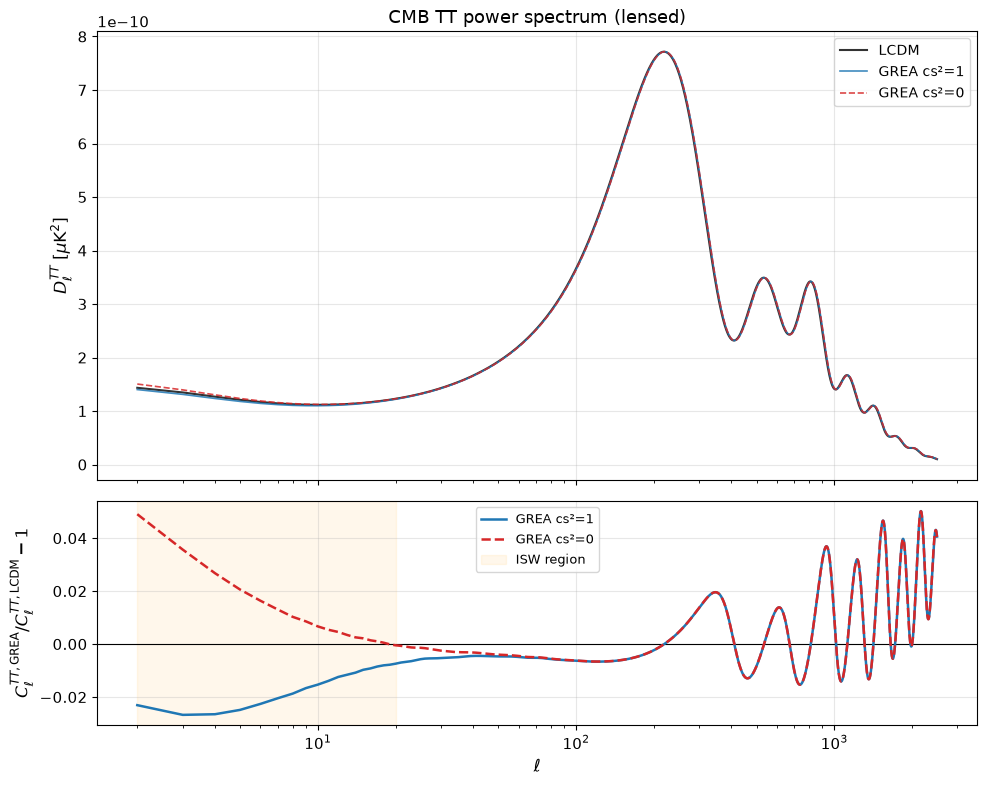

In [15]:
# ── D1: C_ℓ^TT and ratio ─────────────────────────────────────────────────────
lmax = 2500
cl_l = lcdm.lensed_cl(lmax)
cl_g1 = grea1.lensed_cl(lmax)
cl_g0 = grea0.lensed_cl(lmax)

ell = cl_l['ell']
fac = ell * (ell + 1.) / (2. * np.pi)   # standard Dℓ factor

TT_l = fac * cl_l['tt']
TT_g1 = fac * cl_g1['tt']
TT_g0 = fac * cl_g0['tt']

mask = ell >= 2

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
ax, axr = axes

ax.plot(ell[mask], TT_l[mask],  color=COLORS['lcdm'],
        label=LABELS['lcdm'],  lw=1.5)
ax.plot(ell[mask], TT_g1[mask], color=COLORS['grea1'],
        label=LABELS['grea1'], lw=1.2, alpha=0.85)
ax.plot(ell[mask], TT_g0[mask], color=COLORS['grea0'],
        label=LABELS['grea0'], lw=1.2, alpha=0.85, ls='--')
ax.set_xscale('log')
ax.set_ylabel(r'$D_\ell^{TT}$ [$\mu$K$^2$]')
ax.set_title('CMB TT power spectrum (lensed)')
ax.legend()

axr.axhline(0, color='k', lw=0.8)
axr.plot(ell[mask], TT_g1[mask]/TT_l[mask] - 1.,
         color=COLORS['grea1'], label=LABELS['grea1'])
axr.plot(ell[mask], TT_g0[mask]/TT_l[mask] - 1.,
         color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
axr.axvspan(2, 20, alpha=0.08, color='orange', label='ISW region')
axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'$C_\ell^{TT,\rm GREA}/C_\ell^{TT,\rm LCDM} - 1$')
axr.legend(fontsize=9)

plt.tight_layout()
save_fig(fig, 'D1_ClTT')
plt.show()

  saved → D2_Clpp_20260618_154539.png


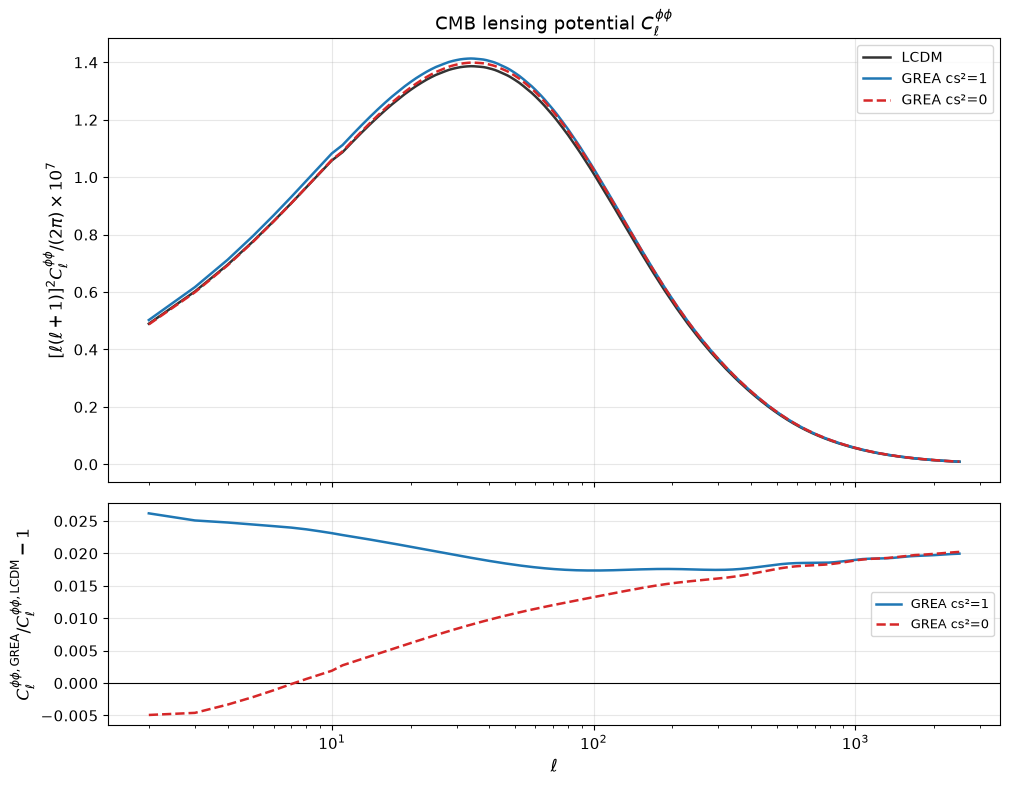

In [16]:
# ── D2: C_ℓ^φφ lensing potential and ratio ───────────────────────────────────
# 'pp' key = C_ℓ^{φφ}; plot ℓ²(ℓ+1)²/(2π) C_ℓ^φφ × 10^7 (standard convention)
fac_pp = (ell * (ell + 1.))**2 / (2. * np.pi) * 1.e7

PP_l = fac_pp * cl_l['pp']
PP_g1 = fac_pp * cl_g1['pp']
PP_g0 = fac_pp * cl_g0['pp']

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
ax, axr = axes

ax.plot(ell[mask], PP_l[mask],  color=COLORS['lcdm'],  label=LABELS['lcdm'])
ax.plot(ell[mask], PP_g1[mask], color=COLORS['grea1'], label=LABELS['grea1'])
ax.plot(ell[mask], PP_g0[mask], color=COLORS['grea0'],
        label=LABELS['grea0'], ls='--')
ax.set_xscale('log')
ax.set_ylabel(r'$[\ell(\ell+1)]^2 C_\ell^{\phi\phi} / (2\pi) \times 10^7$')
ax.set_title(r'CMB lensing potential $C_\ell^{\phi\phi}$')
ax.legend()

axr.axhline(0, color='k', lw=0.8)
good = mask & (PP_l > 0)
axr.plot(ell[good], PP_g1[good]/PP_l[good] - 1.,
         color=COLORS['grea1'], label=LABELS['grea1'])
axr.plot(ell[good], PP_g0[good]/PP_l[good] - 1.,
         color=COLORS['grea0'], label=LABELS['grea0'], ls='--')
axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'$C_\ell^{\phi\phi,\rm GREA}/C_\ell^{\phi\phi,\rm LCDM} - 1$')
axr.legend(fontsize=9)

plt.tight_layout()
save_fig(fig, 'D2_Clpp')
plt.show()

---
## Section E — Parameter Space (PLACEHOLDER)

> **⚠️ This section is a PLACEHOLDER — grid/Fisher forecast only, NOT an MCMC posterior.**
> Replace with real chains (getdist/ChainConsumer) once the Cobaya/MontePython pipeline is built.

A 2D grid scan of `(sqrt_k_eta0, h)` showing how σ₈ varies at fixed omega_b, omega_cdm, A_s, n_s, τ.
This illustrates the GREA parameter sensitivity, not a posterior.


Running 3×3 grid scan (9 CLASS runs, background+mPk only)...
  sqrt_k_eta0=3.0  h=0.67  S8=0.8291
  sqrt_k_eta0=3.0  h=0.70  S8=0.7969
  sqrt_k_eta0=3.0  h=0.73  S8=0.7660
  sqrt_k_eta0=3.6  h=0.67  S8=0.8589
  sqrt_k_eta0=3.6  h=0.70  S8=0.8295
  sqrt_k_eta0=3.6  h=0.73  S8=0.8008
  sqrt_k_eta0=4.2  h=0.67  S8=0.8801
  sqrt_k_eta0=4.2  h=0.70  S8=0.8542
  sqrt_k_eta0=4.2  h=0.73  S8=0.8287
Grid scan complete.
  saved → E_grid_scan_placeholder_20260618_154539.png


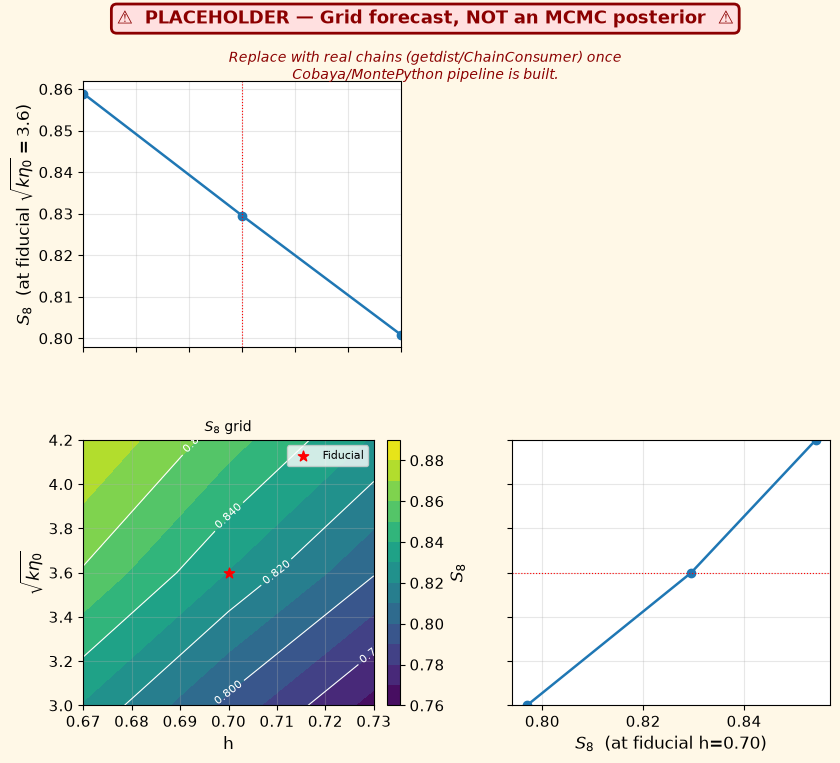

In [17]:
# ── E: Grid scan (sqrt_k_eta0, h) → σ₈  [PLACEHOLDER, NOT A POSTERIOR] ──────
# 3×3 grid; each point requires one CLASS run (background only → fast)
from classy import Class

GRID_K = np.array([3.0, 3.6, 4.2])     # sqrt_k_eta0 values
GRID_H = np.array([0.67, 0.70, 0.73])  # h values
_BASE_GRID = {
    'omega_b': 0.02237, 'omega_cdm': 0.1200,
    'A_s': 2.1e-9, 'n_s': 0.9649, 'tau_reio': 0.0544,
    'output': 'mPk', 'P_k_max_1/Mpc': 3.0,
    'fluid_equation_of_state': 'GREA', 'cs2_fld': 1.0, 'use_ppf': 'yes',
    'base_path': ROOT,
}

print("Running 3×3 grid scan (9 CLASS runs, background+mPk only)...")
S8_grid = np.zeros((len(GRID_K), len(GRID_H)))
for i, gk in enumerate(GRID_K):
    for j, hv in enumerate(GRID_H):
        c = Class()
        c.set({**_BASE_GRID, 'sqrt_k_eta0': gk, 'h': hv})
        try:
            c.compute()
            S8_grid[i, j] = c.S8()
        except Exception as e:
            print(f"  FAILED at sqrt_k_eta0={gk}, h={hv}: {e}")
            S8_grid[i, j] = np.nan
        finally:
            c.struct_cleanup()
            c.empty()
        print(f"  sqrt_k_eta0={gk:.1f}  h={hv:.2f}  S8={S8_grid[i, j]:.4f}")

print("Grid scan complete.")

# ── Triangle-style plot (stub: 2D heatmap + 1D marginals) ────────────────────
fig = plt.figure(figsize=(9, 8))
# light tint to visually flag as placeholder
fig.patch.set_facecolor('#fff8e7')

# Big PLACEHOLDER banner
fig.text(0.5, 0.97, '⚠  PLACEHOLDER — Grid forecast, NOT an MCMC posterior  ⚠',
         ha='center', va='top', fontsize=13, color='darkred', fontweight='bold',
         bbox=dict(boxstyle='round', fc='#ffe0e0', ec='darkred', lw=2))
fig.text(0.5, 0.92,
         'Replace with real chains (getdist/ChainConsumer) once\nCobaya/MontePython pipeline is built.',
         ha='center', va='top', fontsize=10, color='darkred', style='italic')

gs = fig.add_gridspec(2, 2, left=0.12, right=0.95, top=0.88, bottom=0.10,
                      hspace=0.35, wspace=0.35)
ax_main = fig.add_subplot(gs[1, 0])   # bottom-left: 2D heatmap
# top-left: S8 vs sqrt_k_eta0
ax_marg_k = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_marg_h = fig.add_subplot(gs[1, 1], sharey=ax_main)   # bottom-right: S8 vs h

# 2D heatmap
im = ax_main.contourf(GRID_H, GRID_K, S8_grid, levels=12, cmap='viridis')
cs = ax_main.contour(GRID_H, GRID_K, S8_grid, levels=6,
                     colors='w', linewidths=0.8)
ax_main.clabel(cs, inline=True, fontsize=8, fmt='%.3f')
ax_main.scatter([0.70], [3.6], color='red', zorder=5,
                s=60, marker='*', label='Fiducial')
ax_main.set_xlabel('h')
ax_main.set_ylabel(r'$\sqrt{k\eta_0}$')
ax_main.set_title(r'$S_8$ grid', fontsize=10)
ax_main.legend(fontsize=8)
fig.colorbar(im, ax=ax_main, label=r'$S_8$', fraction=0.046, pad=0.04)

# Marginals (slice through fiducial)
ax_marg_k.plot(GRID_H, S8_grid[1, :], 'o-', color=COLORS['grea1'])
ax_marg_k.axvline(0.70, ls=':', color='red', lw=0.8)
ax_marg_k.set_ylabel(r'$S_8$  (at fiducial $\sqrt{k\eta_0}=3.6$)')
plt.setp(ax_marg_k.get_xticklabels(), visible=False)

ax_marg_h.plot(S8_grid[:, 1], GRID_K, 'o-', color=COLORS['grea1'])
ax_marg_h.axhline(3.6, ls=':', color='red', lw=0.8)
ax_marg_h.set_xlabel(r'$S_8$  (at fiducial h=0.70)')
plt.setp(ax_marg_h.get_yticklabels(), visible=False)

save_fig(fig, 'E_grid_scan_placeholder')
plt.show()

---
## Cleanup

In [18]:
for c in [lcdm, grea1, grea0]:
    c.struct_cleanup()
    c.empty()
print(f"All instances freed. Figures saved to {FIGURES_DIR}")
print(f"Run tag: {RUN_TS}")

All instances freed. Figures saved to /Users/simonedonofrio/Desktop/CLASS/class_public-3.3.4/figures
Run tag: 20260618_154539
